In [1]:
import pandas as pd
from rdflib import Graph, URIRef, Literal, Namespace, RDF, XSD

# =====================
# Load CSV file
# =====================
file_path = "students.csv"   # change if your file name is different
df = pd.read_csv(file_path)

In [2]:
# =====================
# Create RDF graph
# =====================
g = Graph()

EX = Namespace("http://example.org/")
FOAF = Namespace("http://xmlns.com/foaf/0.1/")
SCHEMA = Namespace("http://schema.org/")

g.bind("ex", EX)
g.bind("foaf", FOAF)
g.bind("schema", SCHEMA)

students = []

In [3]:
# =====================
# CSV -> RDF Mapping
# =====================
for _, row in df.iterrows():
    student_uri = URIRef(EX["student/" + str(row["StudentID"])])
    students.append((student_uri, row))

    g.add((student_uri, RDF.type, FOAF.Person))

    g.add((student_uri, EX.studentID, Literal(row["StudentID"], datatype=XSD.integer)))
    g.add((student_uri, EX.age, Literal(row["Age"], datatype=XSD.integer)))
    g.add((student_uri, EX.gender, Literal(row["Gender"], datatype=XSD.integer)))
    g.add((student_uri, EX.ethnicity, Literal(row["Ethnicity"], datatype=XSD.integer)))
    g.add((student_uri, EX.parentalEducation, Literal(row["ParentalEducation"], datatype=XSD.integer)))
    g.add((student_uri, EX.studyTimeWeekly, Literal(row["StudyTimeWeekly"], datatype=XSD.float)))
    g.add((student_uri, EX.absences, Literal(row["Absences"], datatype=XSD.integer)))
    g.add((student_uri, EX.tutoring, Literal(row["Tutoring"], datatype=XSD.integer)))
    g.add((student_uri, EX.parentalSupport, Literal(row["ParentalSupport"], datatype=XSD.integer)))
    g.add((student_uri, EX.extracurricular, Literal(row["Extracurricular"], datatype=XSD.integer)))
    g.add((student_uri, EX.sports, Literal(row["Sports"], datatype=XSD.integer)))
    g.add((student_uri, EX.music, Literal(row["Music"], datatype=XSD.integer)))
    g.add((student_uri, EX.volunteering, Literal(row["Volunteering"], datatype=XSD.integer)))
    g.add((student_uri, EX.gpa, Literal(row["GPA"], datatype=XSD.float)))
    g.add((student_uri, EX.gradeClass, Literal(row["GradeClass"], datatype=XSD.integer)))

In [4]:
# =====================
# Discover implicit relations
# =====================
for i in range(len(students)):
    for j in range(i + 1, len(students)):
        s1, r1 = students[i]
        s2, r2 = students[j]

        # Same GradeClass
        if r1["GradeClass"] == r2["GradeClass"]:
            g.add((s1, EX.sameGradeClass, s2))
            g.add((s2, EX.sameGradeClass, s1))

        # Similar GPA (difference < 0.5)
        if abs(r1["GPA"] - r2["GPA"]) < 0.5:
            g.add((s1, EX.similarGPA, s2))
            g.add((s2, EX.similarGPA, s1))

        # Same Age
        if r1["Age"] == r2["Age"]:
            g.add((s1, EX.sameAge, s2))
            g.add((s2, EX.sameAge, s1))

In [5]:
# =====================
# Save RDF graph
# =====================
output_file = "students_graph.ttl"
g.serialize(destination=output_file, format="turtle")

print("Knowledge Graph created successfully!")
print("Saved as:", output_file)

Knowledge Graph created successfully!
Saved as: students_graph.ttl


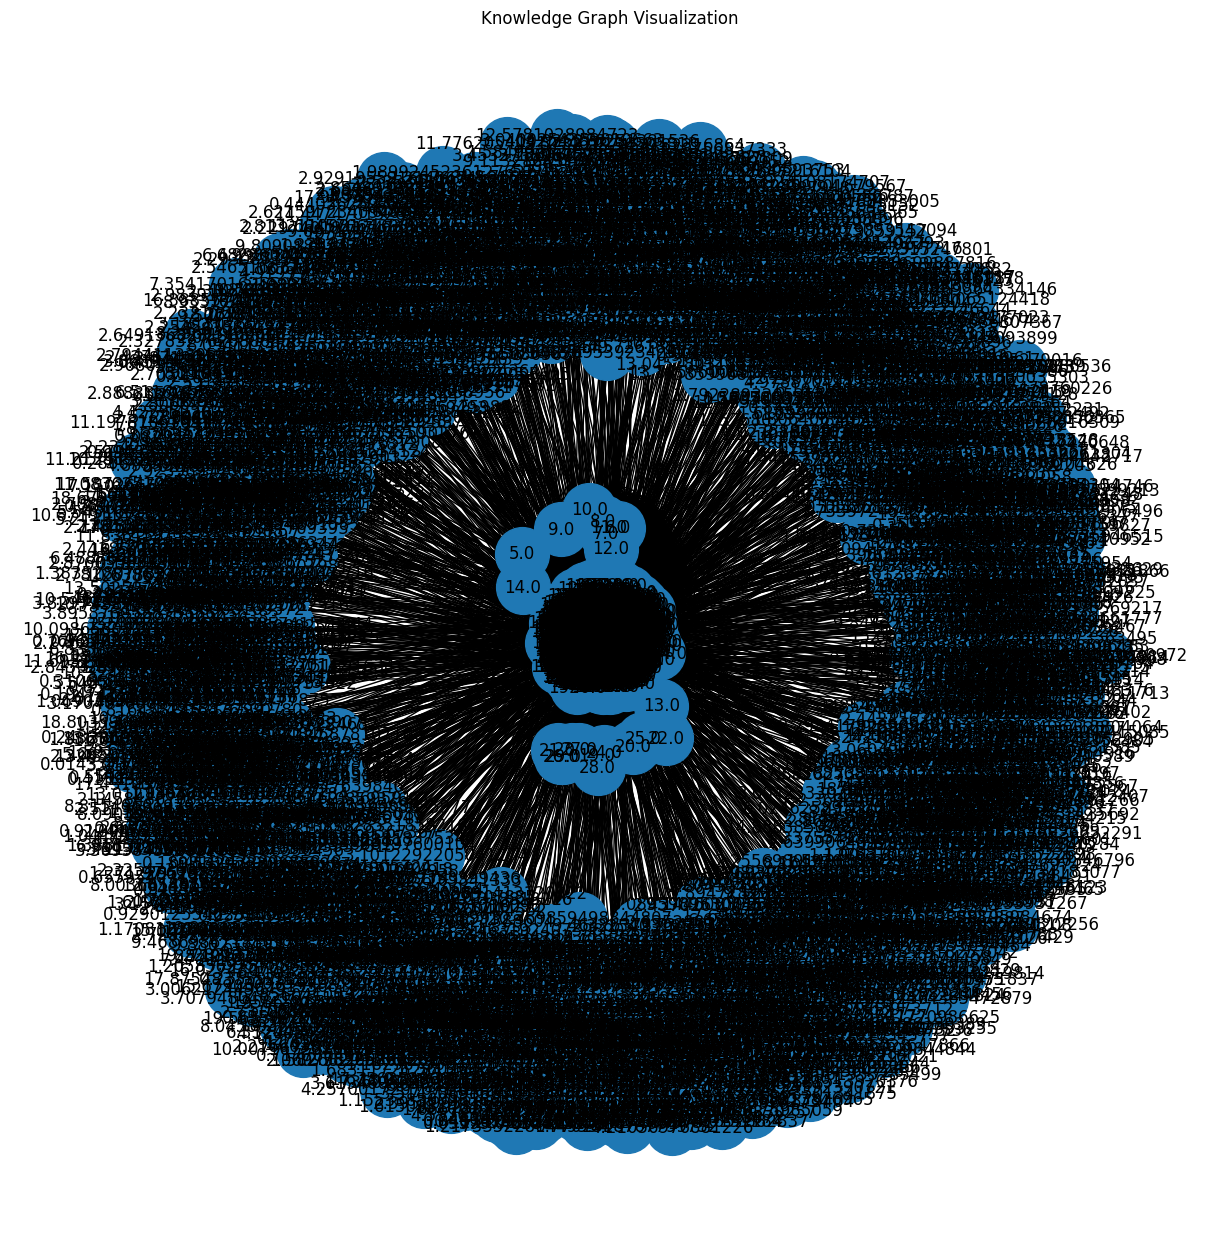

In [6]:
from rdflib import Graph
import networkx as nx
import matplotlib.pyplot as plt

g = Graph()
g.parse("students_graph.ttl", format="turtle")

G = nx.Graph()

for s,p,o in g:
    G.add_edge(str(s).split("/")[-1], str(o).split("/")[-1])

plt.figure(figsize=(12,12))
nx.draw(G, with_labels=True, node_size=1500)
plt.title("Knowledge Graph Visualization")
plt.show()